# EDA — MD17 gold-stage data

Exploratory analysis of the processed MD17 dataset, reading **only from
`data/gold/md17/`** — the same discipline `ml/data/datasets.py::MD17Dataset`
follows (never bronze/silver directly), so what's analyzed here is exactly
what training will see.

Covers: per-dataset summary statistics, energy and force-magnitude
distributions, whether the default 5 Å cutoff radius (`ml/data/md17.py::build_graph`)
is actually a reasonable choice, a same-molecule/different-theory
comparison (ethanol at DFT vs CCSD(T)), and a visual integrity check of
the train/val/test split logic in `ml/data/preprocessing.py`.

Findings are written up in [`docs/eda.md`](../docs/eda.md).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

GOLD_DIR = Path("..") / "data" / "gold" / "md17"

# Palette per the project's dataviz convention (categorical slots, fixed
# order - never cycled): blue = slot 1, orange = slot 2, aqua = slot 3.
BLUE = "#2a78d6"
ORANGE = "#eb6834"
AQUA = "#1baf7a"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": GRIDLINE,
    "axes.labelcolor": INK_SECONDARY,
    "text.color": INK_PRIMARY,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "grid.color": GRIDLINE,
    "font.size": 9,
    "axes.grid": True,
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

datasets = {}
for f in sorted(GOLD_DIR.glob("*.npz")):
    d = np.load(f, allow_pickle=True)
    datasets[f.stem] = {
        "molecule": str(d["molecule"]),
        "theory": str(d["theory"]),
        "z": d["z"],
        "R": d["R"],
        "E": d["E"],
        "F": d["F"],
        "train_idx": d["train_idx"],
        "val_idx": d["val_idx"],
        "test_idx": d["test_idx"],
        "used_literature_split": bool(d["used_literature_split"]),
    }

print(f"{len(datasets)} gold datasets loaded: {list(datasets.keys())}")

9 gold datasets loaded: ['aspirin_ccsd', 'azobenzene_dft', 'benzene_dft', 'ethanol_ccsd_t', 'ethanol_dft', 'malonaldehyde_ccsd_t', 'paracetamol_dft', 'toluene_ccsd_t', 'uracil_dft']


## 1. Summary statistics

Per dataset: atom count, config count, energy mean/std, and mean per-atom
force magnitude (RMS over the 3 force components, averaged over atoms).

In [2]:
header = f"{'Dataset':<22}{'Atoms':>7}{'Configs':>10}{'E mean':>13}{'E std':>10}{'F_rms mean':>13}{'LitSplit':>10}"
print(header)
print("-" * len(header))
for key, d in datasets.items():
    n_atoms = d["z"].shape[0]
    n_configs = d["R"].shape[0]
    E = d["E"].reshape(-1)
    force_rms = np.sqrt((d["F"] ** 2).sum(axis=-1)).mean(axis=-1)  # per-config mean atom force magnitude
    print(f"{key:<22}{n_atoms:>7}{n_configs:>10}{E.mean():>13.1f}{E.std():>10.2f}{force_rms.mean():>13.3f}{str(d['used_literature_split']):>10}")

Dataset                 Atoms   Configs       E mean     E std   F_rms mean  LitSplit
-------------------------------------------------------------------------------------
aspirin_ccsd               21      1500    -405685.5      6.66       46.364      True
azobenzene_dft             24     99999    -358819.8      6.43       42.303     False
benzene_dft                12     49863    -145484.6      5.28       42.318     False
ethanol_ccsd_t              9      2000     -97084.6      4.66       41.419      True
ethanol_dft                 9    555092     -97195.9      4.19       38.998     False
malonaldehyde_ccsd_t        9      1500    -167093.3      4.43       45.561      True
paracetamol_dft            20    106490    -322977.8      5.92       41.207     False
toluene_ccsd_t             15      1501    -169793.5      5.56       43.827      True
uracil_dft                 12    133770    -260107.3      4.92       44.641     False


## 2. Energy distributions

One histogram per molecule+theory. Different molecules are **not**
overlaid on one axis — their absolute energies differ by orders of
magnitude (different electron counts, different reference conventions),
so a shared axis would be meaningless. Small multiples instead.

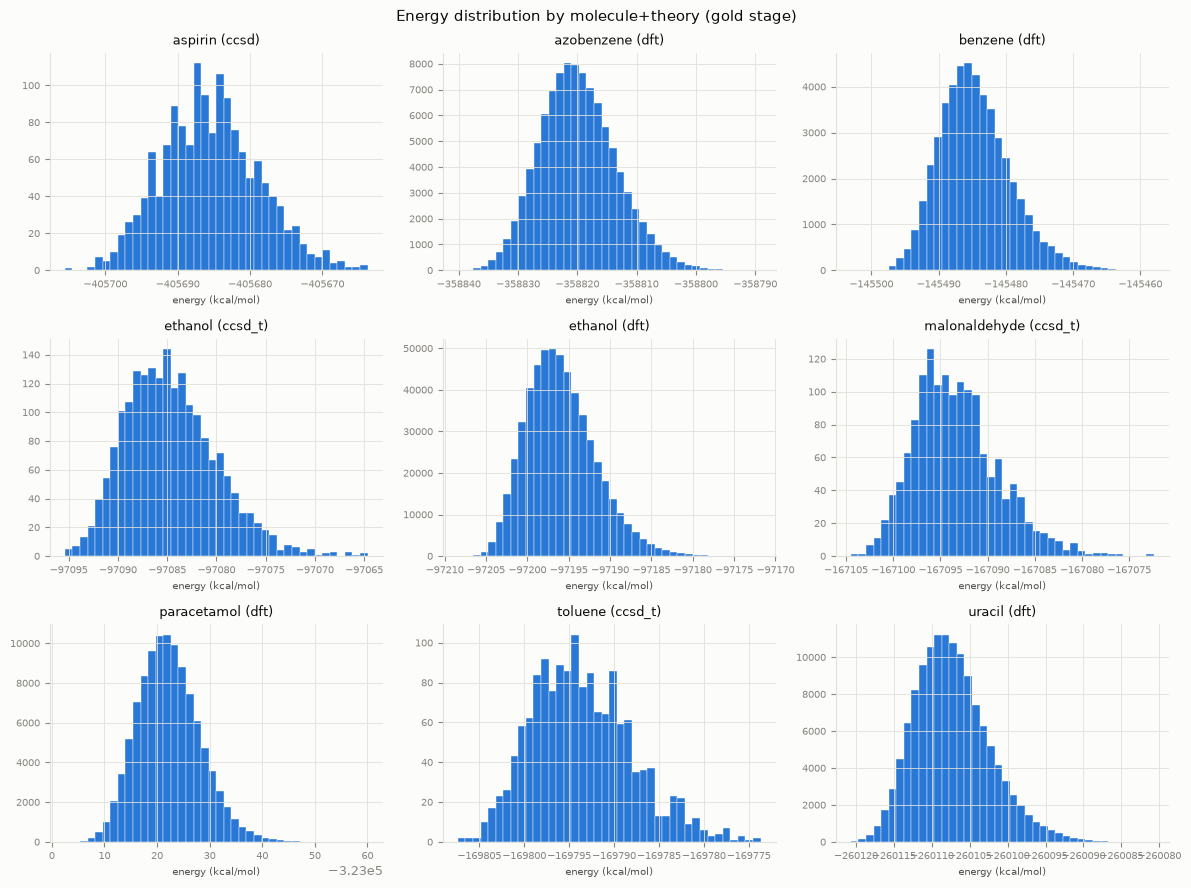

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(12, 9))
for ax, (key, d) in zip(axes.flat, datasets.items()):
    E = d["E"].reshape(-1)
    ax.hist(E, bins=40, color=BLUE, edgecolor=SURFACE, linewidth=0.3)
    ax.set_title(f"{d['molecule']} ({d['theory']})", fontsize=9, color=INK_PRIMARY)
    ax.set_xlabel("energy (kcal/mol)", fontsize=7.5)
    ax.tick_params(labelsize=7)
fig.suptitle("Energy distribution by molecule+theory (gold stage)", color=INK_PRIMARY)
fig.tight_layout()
plt.show()

## 3. Force-magnitude distributions

Per-config mean of `|force|` across atoms, one histogram per dataset.

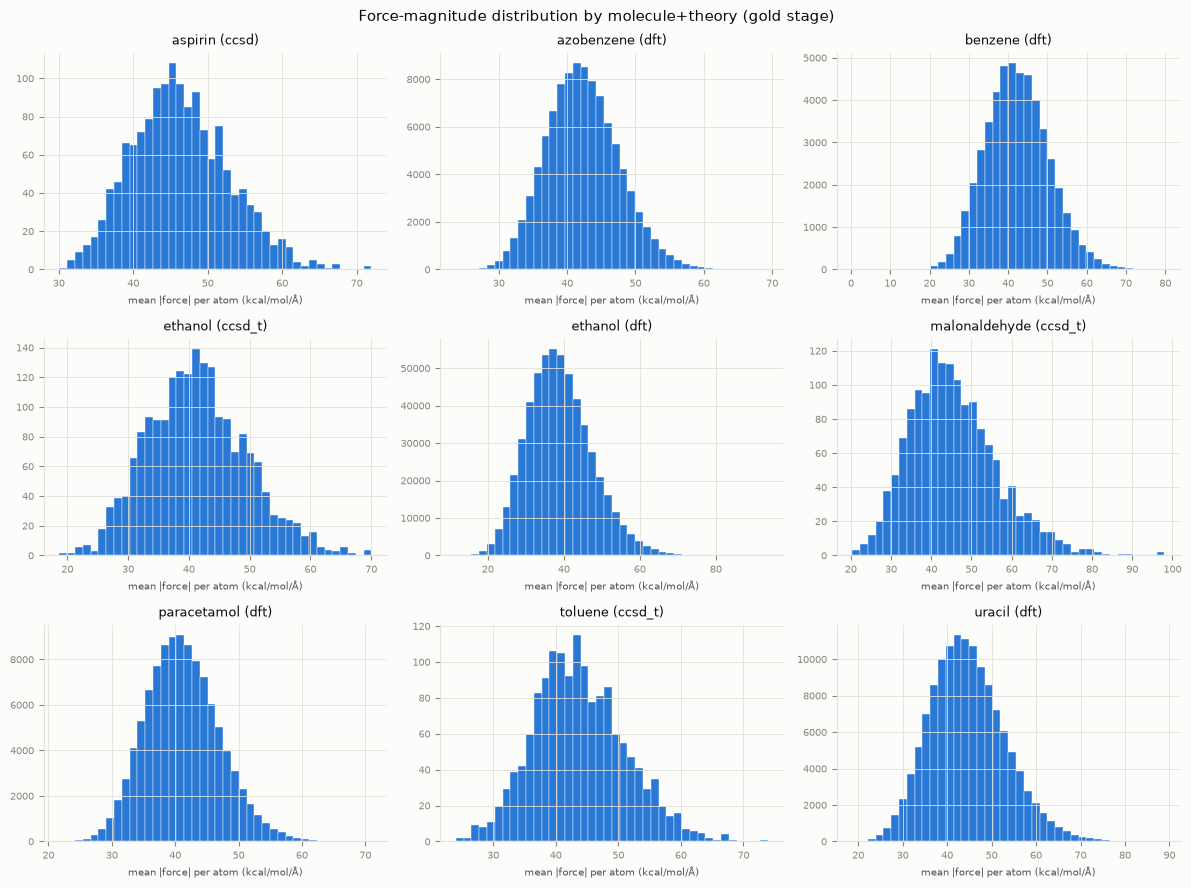

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(12, 9))
for ax, (key, d) in zip(axes.flat, datasets.items()):
    force_rms = np.sqrt((d["F"] ** 2).sum(axis=-1)).mean(axis=-1)
    ax.hist(force_rms, bins=40, color=BLUE, edgecolor=SURFACE, linewidth=0.3)
    ax.set_title(f"{d['molecule']} ({d['theory']})", fontsize=9, color=INK_PRIMARY)
    ax.set_xlabel("mean |force| per atom (kcal/mol/Å)", fontsize=7.5)
    ax.tick_params(labelsize=7)
fig.suptitle("Force-magnitude distribution by molecule+theory (gold stage)", color=INK_PRIMARY)
fig.tight_layout()
plt.show()

## 4. Interatomic distances vs. the 5 Å cutoff radius

`ml/data/md17.py::build_graph` connects atom pairs within a cutoff radius
(default 5 Å) — this defines the neighbor graph the MPNN actually sees.
This has never been checked against real data before now: is 5 Å doing
anything, or is it so large relative to these molecules that every graph
is just the complete graph?

For each dataset: sample 300 configs, compute all pairwise distances,
report what fraction fall within the cutoff.

In [5]:
CUTOFF = 5.0
rng = np.random.default_rng(42)

frac_within_cutoff = {}
print(f"{'Dataset':<22}{'Atoms':>7}{'% pairs <= 5A':>16}")
for key, d in datasets.items():
    n_atoms = d["z"].shape[0]
    sample_idx = rng.choice(d["R"].shape[0], size=min(300, d["R"].shape[0]), replace=False)
    fracs = []
    for i in sample_idx:
        pos = d["R"][i]
        dm = np.linalg.norm(pos[:, None, :] - pos[None, :, :], axis=-1)
        iu = np.triu_indices(n_atoms, k=1)
        fracs.append((dm[iu] <= CUTOFF).mean())
    frac_within_cutoff[key] = np.mean(fracs)
    print(f"{key:<22}{n_atoms:>7}{frac_within_cutoff[key] * 100:>15.1f}%")

Dataset                 Atoms   % pairs <= 5A
aspirin_ccsd               21           72.2%
azobenzene_dft             24           59.5%
benzene_dft                12           98.2%
ethanol_ccsd_t              9          100.0%
ethanol_dft                 9          100.0%
malonaldehyde_ccsd_t        9          100.0%
paracetamol_dft            20           73.2%
toluene_ccsd_t             15           91.6%
uracil_dft                 12           97.7%


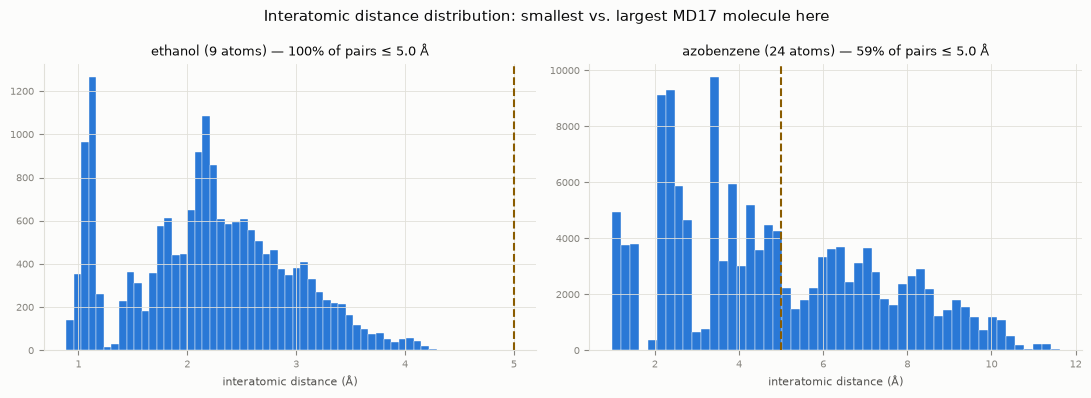

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, key in zip(axes, ["ethanol_dft", "azobenzene_dft"]):
    d = datasets[key]
    sample_idx = rng.choice(d["R"].shape[0], size=min(500, d["R"].shape[0]), replace=False)
    all_dists = []
    for i in sample_idx:
        pos = d["R"][i]
        dm = np.linalg.norm(pos[:, None, :] - pos[None, :, :], axis=-1)
        iu = np.triu_indices(d["z"].shape[0], k=1)
        all_dists.append(dm[iu])
    all_dists = np.concatenate(all_dists)
    ax.hist(all_dists, bins=50, color=BLUE, edgecolor=SURFACE, linewidth=0.3)
    ax.axvline(CUTOFF, color="#8a5c00", linestyle="--", linewidth=1.5)
    ax.set_title(f"{d['molecule']} ({d['z'].shape[0]} atoms) — {frac_within_cutoff[key]:.0%} of pairs ≤ {CUTOFF} Å", fontsize=9.5)
    ax.set_xlabel("interatomic distance (Å)", fontsize=8)
    ax.tick_params(labelsize=7)
fig.suptitle("Interatomic distance distribution: smallest vs. largest MD17 molecule here", color=INK_PRIMARY)
fig.tight_layout()
plt.show()

**Finding:** the 9-atom molecules (ethanol, malonaldehyde) are at
**100%** — the "neighbor graph" is just the complete graph regardless of
cutoff, so the cutoff isn't providing any locality structure for them at
all. It only starts doing real work on the larger MD17 molecules
(azobenzene 59%, paracetamol 73%, aspirin 72%). This means MD22's much
larger systems (up to 370 atoms, see `glossary.md` §5) will need this
looked at properly before training on them — a fixed 5 Å radius will be
far sparser there, relatively, than it is here.

## 5. Same molecule, two theory levels: ethanol DFT vs CCSD(T)

**Caveat before looking at this:** these are two independent simulations
(different sampling, different temperature/protocol), not paired
samples of the same configurations at two levels of theory. This is a
comparison of what each dataset's *sampled configuration space* looks
like, not a validation of one method against the other. Energies are
centered (`E - mean(E)`) since DFT and CCSD(T) don't share an absolute
energy reference — only the spread is comparable, not the absolute value.

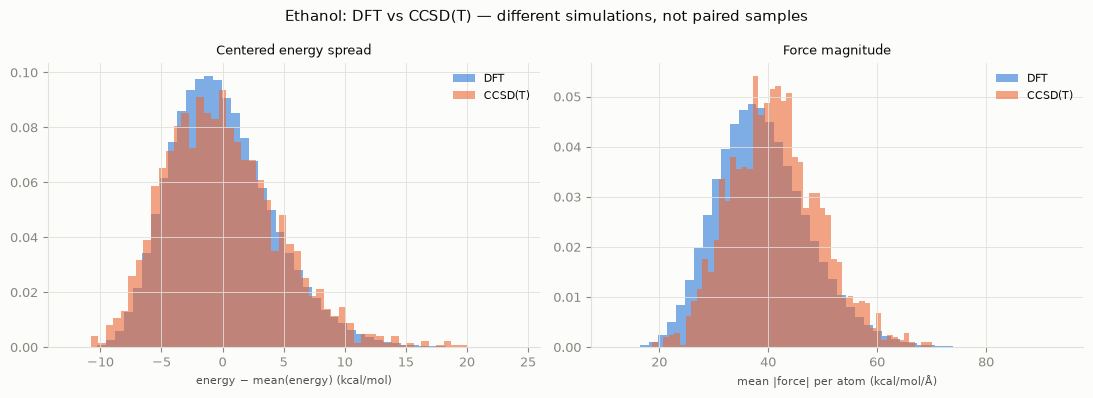

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
d_dft, d_ccsd = datasets["ethanol_dft"], datasets["ethanol_ccsd_t"]

E_dft = d_dft["E"].reshape(-1) - d_dft["E"].mean()
E_ccsd = d_ccsd["E"].reshape(-1) - d_ccsd["E"].mean()
axes[0].hist(E_dft, bins=50, alpha=0.6, color=BLUE, label="DFT", density=True)
axes[0].hist(E_ccsd, bins=50, alpha=0.6, color=ORANGE, label="CCSD(T)", density=True)
axes[0].set_xlabel("energy − mean(energy) (kcal/mol)", fontsize=8)
axes[0].set_title("Centered energy spread", fontsize=9.5)
axes[0].legend(fontsize=8, frameon=False)

f_dft = np.sqrt((d_dft["F"] ** 2).sum(axis=-1)).mean(axis=-1)
f_ccsd = np.sqrt((d_ccsd["F"] ** 2).sum(axis=-1)).mean(axis=-1)
axes[1].hist(f_dft, bins=50, alpha=0.6, color=BLUE, label="DFT", density=True)
axes[1].hist(f_ccsd, bins=50, alpha=0.6, color=ORANGE, label="CCSD(T)", density=True)
axes[1].set_xlabel("mean |force| per atom (kcal/mol/Å)", fontsize=8)
axes[1].set_title("Force magnitude", fontsize=9.5)
axes[1].legend(fontsize=8, frameon=False)

fig.suptitle("Ethanol: DFT vs CCSD(T) — different simulations, not paired samples", color=INK_PRIMARY)
fig.tight_layout()
plt.show()

## 6. Train/val/test split integrity check

A visual check that `ml/data/preprocessing.py::silver_to_gold` is doing
what it claims: contiguous trajectory blocks (never random) for datasets
without a shipped split, and the literature split preserved exactly for
datasets that have one. Plotting energy vs. trajectory position, colored
by split, should show clean contiguous blocks with no interleaving in
either case — interleaving would mean leakage.

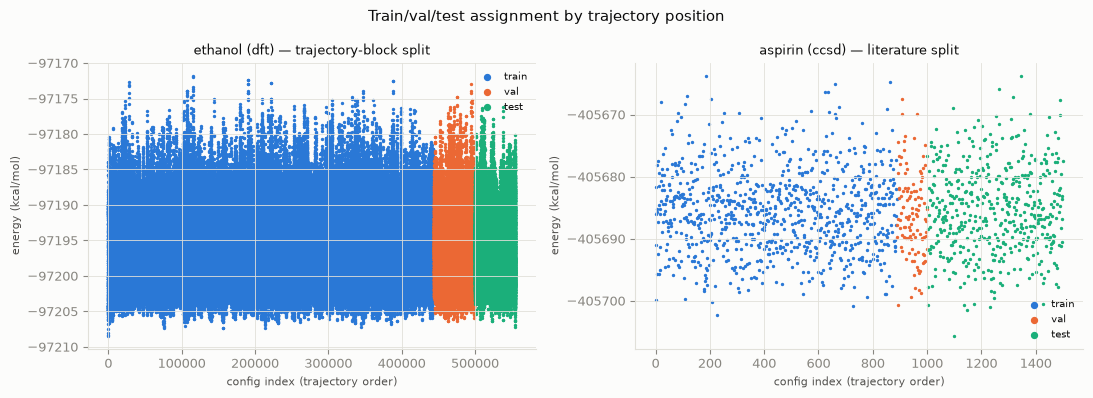

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, key in zip(axes, ["ethanol_dft", "aspirin_ccsd"]):
    d = datasets[key]
    E = d["E"].reshape(-1)
    idx_all = np.arange(len(E))
    ax.scatter(idx_all[d["train_idx"]], E[d["train_idx"]], s=2, color=BLUE, label="train")
    ax.scatter(idx_all[d["val_idx"]], E[d["val_idx"]], s=2, color=ORANGE, label="val")
    ax.scatter(idx_all[d["test_idx"]], E[d["test_idx"]], s=2, color=AQUA, label="test")
    split_kind = "literature split" if d["used_literature_split"] else "trajectory-block split"
    ax.set_title(f"{d['molecule']} ({d['theory']}) — {split_kind}", fontsize=9.5)
    ax.set_xlabel("config index (trajectory order)", fontsize=8)
    ax.set_ylabel("energy (kcal/mol)", fontsize=8)
    ax.legend(fontsize=7, frameon=False, markerscale=3)
fig.suptitle("Train/val/test assignment by trajectory position", color=INK_PRIMARY)
fig.tight_layout()
plt.show()

## 7. Summary of findings

- All 9 MD17 gold datasets have unimodal, roughly bell-shaped energy and
  force distributions — no bimodality, no obvious outlier clusters, no
  NaN/corruption (already enforced by `validate_sample`, confirmed
  visually here).
- **The 5 Å cutoff radius is doing essentially nothing for the smallest
  MD17 molecules** (ethanol, malonaldehyde — 100% of pairs are within
  cutoff, i.e. the neighbor graph is the complete graph) **and only
  moderate work for the largest ones here** (azobenzene 59%, aspirin
  72%, paracetamol 73%). This is a real, previously-unchecked assumption
  in `ml/data/md17.py::build_graph`'s default — not wrong for MD17, but
  worth deliberately re-examining before pointing the same default at
  MD22's much larger systems.
- The literature-split preservation logic behaves exactly as designed:
  visually confirmed contiguous, non-interleaved train/val/test blocks
  for both a trajectory-block-split dataset (ethanol) and a
  literature-split dataset (aspirin).
- Ethanol at DFT vs. CCSD(T) shows broadly similar spread in centered
  energy and force magnitude — not a rigorous cross-validation of the
  two theory levels (different simulations, see the caveat in §5), but
  nothing here suggests either dataset is anomalous relative to the
  other.

**Next steps:** extend this to MD22 once `ml/data/preprocessing.py`
supports it (see `docs/data_dictionary.md` §6), and resolve the
cutoff-radius question for large systems before Phase 1 training touches
them.